implementing multiple linear regression

objective

 * to predict the profit made by a startup on the basis of expenses incurred and the state where they operate


In [ ]:
# importing the libraries
import numpy as np
import pandas as pd
#from numpy import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Copy of 50_Startups.csv')
df.head()

In [ ]:
df.shape

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Text(0, 0.5, 'Profit')

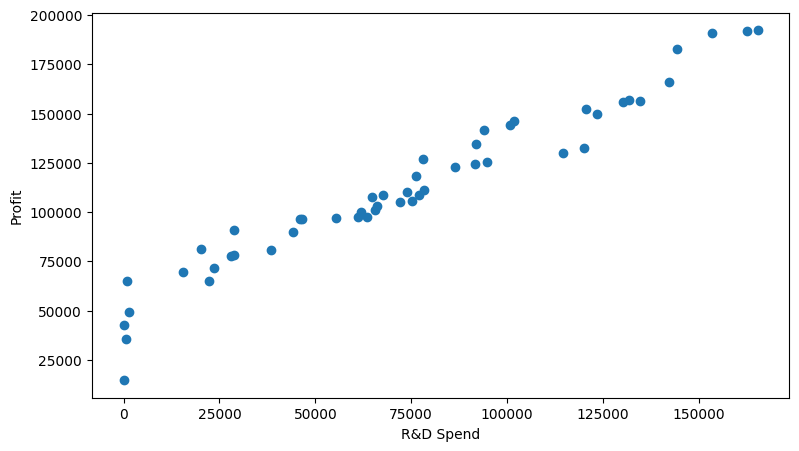

In [11]:
plt.figure(figsize=(9,5))
plt.scatter(df['R&D Spend'], df['Profit'])
plt.xlabel('R&D Spend')
plt.ylabel('Profit')

Text(0, 0.5, 'Profit')

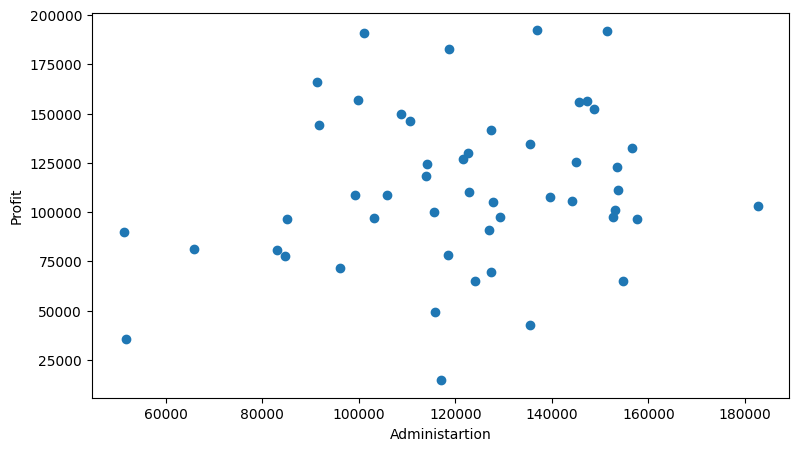

In [12]:
plt.figure(figsize=(9,5))
plt.scatter(df['Administration'], df['Profit'])
plt.xlabel('Administartion')
plt.ylabel('Profit')

Text(0, 0.5, 'Profit')

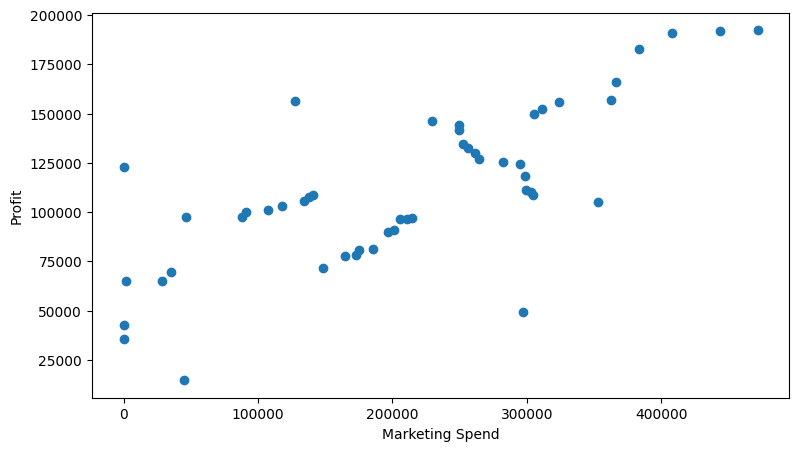

In [13]:
plt.figure(figsize=(9,5))
plt.scatter(df['Marketing Spend'], df['Profit'])
plt.xlabel('Marketing Spend')
plt.ylabel('Profit')

In [14]:
df.groupby(['State']) ['Profit'].mean()

,Profit
State,
California,103905.175294
Florida,118774.024375
New York,113756.446471


<Axes: xlabel='State'>

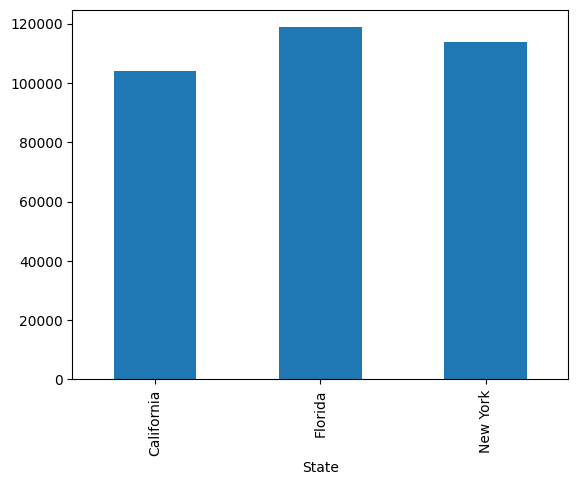

In [15]:
df.groupby(['State']) ['Profit'].mean().plot(kind='bar')

In [16]:
df['State'].head()

,State
0,New York
1,California
2,Florida
3,New York
4,Florida


In [17]:
df['New York_state'] = np.where(df['State']=='New York' , 1,0)
df['California_state'] = np.where(df['State']=='california' , 1,0)
df['Florida_state'] = np.where(df['State']=='florida' , 1,0)



In [18]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit,New York_state,California_state,Florida_state
0,165349.20,136897.80,471784.10,New York,192261.83,1,0,0
1,162597.70,151377.59,443898.53,California,191792.06,0,0,0
2,153441.51,101145.55,407934.54,Florida,191050.39,0,0,0
3,144372.41,118671.85,383199.62,New York,182901.99,1,0,0
4,142107.34,91391.77,366168.42,Florida,166187.94,0,0,0


In [19]:
df.drop(columns = ['State'], inplace = True )

In [20]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,New York_state,California_state,Florida_state
0,165349.20,136897.80,471784.10,192261.83,1,0,0
1,162597.70,151377.59,443898.53,191792.06,0,0,0
2,153441.51,101145.55,407934.54,191050.39,0,0,0
3,144372.41,118671.85,383199.62,182901.99,1,0,0
4,142107.34,91391.77,366168.42,166187.94,0,0,0


In [21]:
x =  df.drop(columns =['Profit'])
y = df['Profit']

In [22]:
x.head()

,R&D Spend,Administration,Marketing Spend,New York_state,California_state,Florida_state
0,165349.20,136897.80,471784.10,1,0,0
1,162597.70,151377.59,443898.53,0,0,0
2,153441.51,101145.55,407934.54,0,0,0
3,144372.41,118671.85,383199.62,1,0,0
4,142107.34,91391.77,366168.42,0,0,0


In [23]:
y.head()

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94


In [24]:
X_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [25]:
X_train.shape

(40, 6)

In [26]:
x_test.shape

(10, 6)

In [27]:
model = LinearRegression()

In [36]:
model.fit(X_train, y_train)

LinearRegression()

In [29]:
model.coef_

array([ 8.04487705e-01, -6.78772133e-02,  3.11570269e-02, -4.89186963e+02,
        0.00000000e+00,  0.00000000e+00])

In [30]:
X_train.head()

,R&D Spend,Administration,Marketing Spend,New York_state,California_state,Florida_state
12,93863.75,127320.38,249839.44,0,0,0
4,142107.34,91391.77,366168.42,0,0,0
37,44069.95,51283.14,197029.42,0,0,0
8,120542.52,148718.95,311613.29,1,0,0
3,144372.41,118671.85,383199.62,1,0,0


In [31]:
model.predict([[93863.75,	127320.38,	249839.44,	0,	0,	1,]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([128843.78996758])

In [32]:
y_train.head(1)

,Profit
12,141585.52
